# Baselines Models

Two baselines evaluated on RMSE and MAE:

| Model | Description |
|-------|-------------|
| **Popularity** | Recommend top-N most-rated games to all users; predict with per-game mean rating |
| **User-Based KNN** | Find k most similar users via cosine similarity; predict as weighted average of their ratings |

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csc_matrix


In [2]:
path = kagglehub.dataset_download("threnjen/board-games-database-from-boardgamegeek")
print(f"Path to dataset files: {path}")

games = pd.read_csv(f"{path}/games.csv")
user_ratings = pd.read_csv(f"{path}/user_ratings.csv")
mechanics = pd.read_csv(f"{path}/mechanics.csv")
subcategories = pd.read_csv(f"{path}/subcategories.csv")

print(f"games: {games.shape}")
print(f"user_ratings: {user_ratings.shape}")
print(f"mechanics: {mechanics.shape}")
print(f"subcategories: {subcategories.shape}")

Using Colab cache for faster access to the 'board-games-database-from-boardgamegeek' dataset.
Path to dataset files: /kaggle/input/board-games-database-from-boardgamegeek
games: (21925, 48)
user_ratings: (18942215, 3)
mechanics: (21925, 158)
subcategories: (21925, 11)


### Train / Test Split

In [3]:
min_ratings = 5
active_users = user_ratings.groupby('Username').filter(lambda x: len(x) >= min_ratings)
print(f"Ratings after filtering users with <{min_ratings} ratings: {len(active_users):,}")
print(f"Users remaining: {active_users['Username'].nunique():,}")

# 80/20 split
train, test = train_test_split(active_users, test_size=0.2, random_state=42)
print(f"\nTrain size : {len(train):,}")
print(f"Test size : {len(test):,}")

global_mean = train['Rating'].mean()
print(f"\nGlobal mean (train): {global_mean:.4f}")

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

Ratings after filtering users with <5 ratings: 18,696,365
Users remaining: 272,184

Train size : 14,957,092
Test size : 3,739,273

Global mean (train): 7.1118


### Baseline 1: Popularity-Based Ranking

In [4]:
game_mean = train.groupby('BGGId')['Rating'].mean()
game_names = games.set_index('BGGId')['Name']


preds_pop = test['BGGId'].map(game_mean).fillna(global_mean)
rmse_pop = rmse(test['Rating'], preds_pop)
mae_pop = mae(test['Rating'],  preds_pop)

print(f"Popularity baseline (per-game mean)")
print(f"RMSE : {rmse_pop:.4f}")
print(f"MAE : {mae_pop:.4f}")

print("\nTop 10 games to recommend (by number of train ratings):")
top_pop = (train.groupby('BGGId')
               .agg(n_ratings=('Rating','count'), avg_rating=('Rating','mean'))
               .sort_values('n_ratings', ascending=False)
               .head(10))
top_pop['Name'] = top_pop.index.map(game_names)
display(top_pop[['Name','n_ratings','avg_rating']].reset_index(drop=True))

Popularity baseline (per-game mean)
RMSE : 1.3196
MAE : 1.0012

Top 10 games to recommend (by number of train ratings):


,Name,n_ratings,avg_rating
0,Pandemic,84389,7.638829
1,Carcassonne,83985,7.454927
2,Catan,82495,7.170982
3,7 Wonders,69947,7.780845
4,Dominion,63548,7.647983
5,Ticket to Ride,59363,7.456481
6,Codenames,57950,7.675544
7,Terraforming Mars,55356,8.505254
8,7 Wonders Duel,53136,8.183961
9,Agricola,51356,7.971187


### Baseline 2: User-Based Collaborative Filtering (KNNBasic)

Implements the same algorithm as `surprise.KNNBasic`:
- Build a sparse user-item ratings matrix
- Compute user-user **cosine similarity**
- Predict as the **weighted average** of the k nearest neighbors who rated that item
- Falls back to global mean when no neighbor overlap exists

In [5]:
MIN_RATINGS_KNN = 20
active = train.groupby('Username').filter(lambda x: len(x) >= MIN_RATINGS_KNN)
print(f"Users with >= {MIN_RATINGS_KNN} train ratings: {active['Username'].nunique():,}")

SAMPLE_USERS = 15_000
np.random.seed(42)
sampled_users = np.random.choice(active['Username'].unique(), size=SAMPLE_USERS, replace=False)
sample_train = active[active['Username'].isin(sampled_users)]
print(f"Sampled {SAMPLE_USERS:,} users  |  {len(sample_train):,} ratings")

user_enc = LabelEncoder().fit(sample_train['Username'])
game_enc = LabelEncoder().fit(sample_train['BGGId'])

u_idx = user_enc.transform(sample_train['Username'])
g_idx = game_enc.transform(sample_train['BGGId'])

n_users_knn = len(user_enc.classes_)
n_games_knn = len(game_enc.classes_)

R = csr_matrix(
    (sample_train['Rating'].values, (u_idx, g_idx)),
    shape=(n_users_knn, n_games_knn)
)
print(f"\nSparse matrix shape : {R.shape}")
print(f"Stored values : {R.nnz:,}")

Users with >= 20 train ratings: 150,634
Sampled 15,000 users  |  1,350,517 ratings

Sparse matrix shape : (15000, 21538)
Stored values : 1,348,330


In [6]:

#Compute user-user cosine similarity
sim_matrix = cosine_similarity(R)
np.fill_diagonal(sim_matrix, 0)
print(f"Similarity matrix shape: {sim_matrix.shape}")

Similarity matrix shape: (15000, 15000)


In [7]:
K = 40

# To speed up compile run for this cell, we use CSC format for fast column (per-game) slicing
R_csc = R.tocsc()

# We use dict lookups instead of LabelEncoder.transform() per row to also speed things up
user_to_idx = {u: i for i, u in enumerate(user_enc.classes_)}
game_to_idx = {g: i for i, g in enumerate(game_enc.classes_)}

def predict_knn(username, bgg_id):
    u = user_to_idx.get(username)
    g = game_to_idx.get(bgg_id)
    if u is None or g is None:
        return global_mean

    item_col = R_csc[:, g].toarray().ravel()
    rated_mask = item_col > 0
    sim_scores = sim_matrix[u] * rated_mask

    top_k_idx = np.argpartition(sim_scores, -K)[-K:]
    top_k_sims = sim_scores[top_k_idx]
    top_k_rates = item_col[top_k_idx]

    denom = top_k_sims.sum()
    if denom == 0:
        return global_mean

    return float(np.clip(np.dot(top_k_sims, top_k_rates) / denom, 1, 10))

test_knn = test[test['Username'].isin(user_to_idx) & test['BGGId'].isin(game_to_idx)]
print(f"Test pairs evaluable by KNN : {len(test_knn):,}  (of {len(test):,} total)")

preds_knn = [predict_knn(row.Username, row.BGGId) for row in test_knn.itertuples()]
rmse_knn = rmse(test_knn['Rating'], preds_knn)
mae_knn = mae(test_knn['Rating'], preds_knn)

print(f"\nUser-Based KNN (k={K})")
print(f"RMSE: {rmse_knn:.4f}")
print(f"MAE: {mae_knn:.4f}")

Test pairs evaluable by KNN : 334,648  (of 3,739,273 total)

User-Based KNN (k=40)
RMSE: 1.3080
MAE: 0.9987


### Results & Key Metrics

,Model,RMSE,MAE
0,User-Based KNN (k=40),1.3080,0.9987
1,Popularity (per-game mean),1.3196,1.0012


/tmp/ipykernel_17188/262009120.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results['Model'], rotation=10, ha='right')
/tmp/ipykernel_17188/262009120.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results['Model'], rotation=10, ha='right')


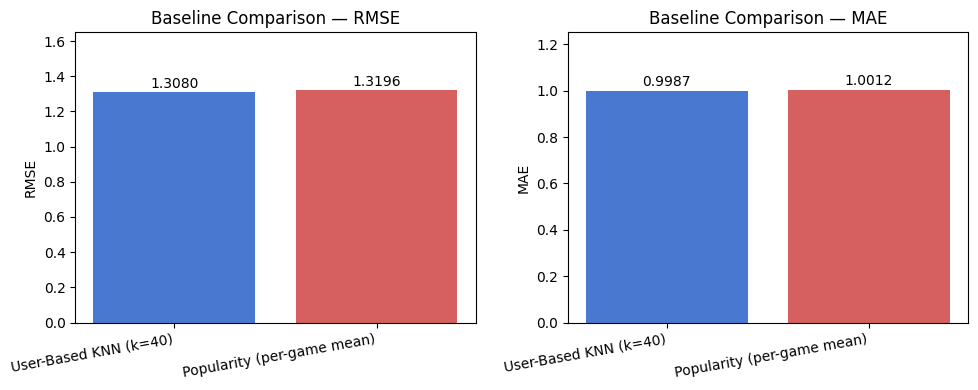

In [8]:
results = pd.DataFrame({
    "Model": ["Popularity (per-game mean)", f"User-Based KNN (k={K})"],
    "RMSE": [rmse_pop, rmse_knn],
    "MAE": [mae_pop,  mae_knn],
})
results = results.sort_values('RMSE').reset_index(drop=True)
display(results.style.format({'RMSE': '{:.4f}', 'MAE': '{:.4f}'}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#4878CF', '#D65F5F']

for ax, metric in zip(axes, ['RMSE', 'MAE']):
    bars = ax.bar(results['Model'], results[metric], color=colors)
    ax.set_title(f'Baseline Comparison — {metric}')
    ax.set_ylabel(metric)
    ax.set_ylim(0, results[metric].max() * 1.25)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    ax.set_xticklabels(results['Model'], rotation=10, ha='right')

plt.tight_layout()
plt.show()